# GeoMx Dataset setup and QC
### Kidney dataset
**Author:** Diana Vera Cruz


## Introduction

This tutorial was created to provide a step-by-step guide on how to set up a dataset for GeoMx analysis. This tutorial was inspired by the [GeoMxTools Tutorial](https://www.bioconductor.org/packages/release/workflows/vignettes/GeoMxWorkflows/inst/doc/GeomxTools_RNA-NGS_Analysis.html), which also uses this dataset. The tutorial will cover the following steps:

  1. Load and process the raw data
  
  2. Perform quality control (QC) analysis: Segment and probe QC
  
  3. Generate a dataset object for downstream analysis
  

### Dataset

FFPE and FF tissue sections from 4 diabetic kidney disease (DKD) and 3 healthy kidney sections [Merritt et al., 2020](https://pubmed.ncbi.nlm.nih.gov/32393914/), processed using the GeoMx Digital Spatial Profiler (DSP) platform. The ROI were profiled to focus on tubules or glomeruli regions. 

  * Glomeruli: Each ROIs defined as glomeruli contains a single glomerulus.
  
  * Tubular: Each ROI contains multiple tubules, and are further classified into distal (PanCK+) or proximal (PanCK-) AOIs.
  
**For this workshop, we simulated 3 columns: Number of nuclei, and X and Y coordinates per ROI, since the original data did not have these fields.**
  
## Raw data 

To generate the complete dataset object we will need 3 types of files: 
  
  1.  **Annotation file**: Excel table with metadata information about each ROI and segment.

  2.  **DCC files**: Expression count data and sequencing quality data: One file per segment (ROI, AOI).

  3.  **PKC files**: Probes / genes level information. Normally is just one, for the organism of reference.


### Considerations prior to data loading

One of the key issues when loading the data is missing information from the segments metadata, that is available in the annotation excel. This is normally due to the fact that the columns are not named as expected. Upper or lower case names seem to work, but you can try various alternatives to make sure this data is available after creating the object.

Make sure you have columns for: 
  
  * Sample_ID: Unique identifier for each segment, this also match the DCC files names.
  * Slide: 
  * ROI: ROI or roi is a good option. 
  * AOI: AOI or aoi is a good option.
  * Area: Area of the segment. area, segment_area, etc.
  * Nuclei: Number of nuclei in the segment. 
  * Coordinate_X/Y: X and Y coordinates of the segment, needed for spatial analysis (SpatialExperiment objects, Seurat, etc)

Since various of these columns are used for the QC, it is important to have them available, you can notice if they are correct or not in the QC parameters table that defines whether a segment passes or not the QC for each of the parameters.
Other columns will be added in the final object and come from the DCC themselves.

## Loading data

### Raw data: DCC, PKC and annotation 

Within the annotation excel, make sure you have the columns needed as metadata for the segments: ROI/AOIs. In this case, the columns with relevant information are region, segment and class.

In [423]:
out_dir = './GeoMx' ## Or full path for the desired output directory.

In [424]:
## cd /gpfs/data/biocore-workshop/spatial_transcriptomics_bruker_2026_workshop2
## sbatch --mem=10G  ./launch_jupyter_conda.sh /gpfs/data/biocore-workshop/spatial_transcriptomics_bruker_2026_workshop2/conda_envs/geomx_env

knitr::opts_chunk$set(message = FALSE)
## LIBRARIES
## Libraries can be installed through Bioconductor: BicManager::install("package_name")
library("tidyverse")
library("readxl")
library("GeomxTools") 
library("SpatialExperiment")
library("ggalluvial")

## Create output directories. -> All output goes to the results directory. 
out_dir = file.path(out_dir, 'results')
# if(!dir.exists(file.path(out_dir, 'env'))) dir.create( file.path(out_dir, 'env') )
if(!dir.exists( out_dir )) dir.create( out_dir, recursive = T)

In [425]:
print(out_dir)

[1] "./GeoMx/results"


In [426]:
## Input directory. 
input_dir = '/gpfs/data/biocore-workshop/spatial_transcriptomics_bruker_2026_workshop2/data/GeoMx_Human_kidney'
## DCC files. 
dcc_dir <- paste0(input_dir, '/dccs')
DCC_files <- list.files(dcc_dir, pattern = ".dcc", full.names = TRUE)
length(DCC_files)
DCC_files[1:5]

## PKC file: Make sure it is unzipped. 
PKC_file <- paste0(input_dir, '/pkcs/TAP_H_WTA_v1.0.pkc')

## Annotation file: 
annotation_file <- paste0(input_dir, '/kidney_demo_AOI_Annotations.xlsx')
## Check that the annotation file has rows that match the names in the DCC files vector. 
## Also, there has to be a first line for the negative control. 
read_excel(annotation_file) %>% head %>% str

## Define which are the columns of interest to keep in metadata tables 
#meta_cols <- c('Sample_ID', 'slide_name', 'region', 'segment', 'class', 'aoi', 'roi', 'area', 'nuclei', 'pathology')

[1] 281

[1] "/gpfs/data/biocore-workshop/spatial_transcriptomics_bruker_2026_workshop2/data/GeoMx_Human_kidney/dccs/DSP-1001250007851-H-A01.dcc"
[2] "/gpfs/data/biocore-workshop/spatial_transcriptomics_bruker_2026_workshop2/data/GeoMx_Human_kidney/dccs/DSP-1001250007851-H-A02.dcc"
[3] "/gpfs/data/biocore-workshop/spatial_transcriptomics_bruker_2026_workshop2/data/GeoMx_Human_kidney/dccs/DSP-1001250007851-H-A03.dcc"
[4] "/gpfs/data/biocore-workshop/spatial_transcriptomics_bruker_2026_workshop2/data/GeoMx_Human_kidney/dccs/DSP-1001250007851-H-A04.dcc"
[5] "/gpfs/data/biocore-workshop/spatial_transcriptomics_bruker_2026_workshop2/data/GeoMx_Human_kidney/dccs/DSP-1001250007851-H-A05.dcc"

tibble [6 × 15] (S3: tbl_df/tbl/data.frame)
 $ Sample_ID      : chr [1:6] "DSP-1001250007851-H-A01" "DSP-1001250007851-H-A02" "DSP-1001250007851-H-A03" "DSP-1001250007851-H-A04" ...
 $ construct      : chr [1:6] "directPCR" "directPCR" "directPCR" "directPCR" ...
 $ instrument_type: chr [1:6] "NextSeq" "NextSeq" "NextSeq" "NextSeq" ...
 $ read_pattern   : chr [1:6] "2x27" "2x27" "2x27" "2x27" ...
 $ expected_neg   : num [1:6] 1 0 0 0 0 0
 $ panel          : chr [1:6] "WTX" "WTX" "WTX" "WTX" ...
 $ slide_name     : chr [1:6] "No Template Control" "disease3" "disease3" "disease3" ...
 $ class          : chr [1:6] NA "DKD" "DKD" "DKD" ...
 $ roi            : num [1:6] NA 7 8 9 10 11
 $ segment        : chr [1:6] NA "Geometric Segment" "Geometric Segment" "Geometric Segment" ...
 $ aoi            : chr [1:6] NA "Geometric Segment-aoi-001" "Geometric Segment-aoi-001" "Geometric Segment-aoi-001" ...
 $ area           : num [1:6] NA 31798 16920 14312 20033 ...
 $ region         : chr [1:6] NA

In [427]:
geomxdt <- readNanoStringGeoMxSet(dccFiles = DCC_files, 
                                  pkcFiles = PKC_file, 
                                  phenoDataFile = annotation_file, 
                                  phenoDataSheet = 'Template', ## Sheet name in excel annotation file. 
                                  phenoDataDccColName = 'Sample_ID',
                                  protocolDataColNames = c('aoi','roi'),
                                  experimentDataColNames = c('panel')
                                  )
## Save object. 
saveRDS(geomxdt, file = file.path(out_dir,'geomxdt_raw.rds'))

Warning message in readNanoStringGeoMxSet(dccFiles = DCC_files, pkcFiles = PKC_file, :
“The following DCC files had no counts: DSP-1001250007864-D-C10.dcc, These will be excluded from the GeoMxSet object.”


### NanoStringGeoMxSet object

The object is a `NanoStringGeoMxSet` object, which is a subclass of `SummarizedExperiment`.
The object contains various slots, the most relevant are:
  
  * `pData`: Contains the metadata information per segment. pData(geomxdt)
  
  * `sData`: Contains the extended version of the metadata, protocol and other general information of the study present in the annotation file. 
  
  * `protocolData`: Contains all the metadata for the study run. Used for assigning new values. 
  
  * `annotation`: Contains the annotation information: PKC file used. 
  
  * `fData`: Contains the feature information.
  
The object also includes various assay names, normally used to store raw counts and normalizations and other transformations. 

  * assayDataElement(geomx_obj, elt = "assay)name")

In [428]:
geomxdt <- readRDS(file = file.path(out_dir,'geomxdt_raw.rds'))
dim(geomxdt)

Features  Samples 
   18642      280

**sData columns**

In [429]:
sData(geomxdt) %>% names

[1] "construct"         "instrument_type"   "read_pattern"     
 [4] "expected_neg"      "slide_name"        "class"            
 [7] "segment"           "area"              "region"           
[10] "pathology"         "nuclei"            "FileVersion"      
[13] "SoftwareVersion"   "Date"              "SampleID"         
[16] "Plate_ID"          "Well"              "SeqSetId"         
[19] "Raw"               "Trimmed"           "Stitched"         
[22] "Aligned"           "umiQ30"            "rtsQ30"           
[25] "DeduplicatedReads" "roi"               "aoi"

**pData structure**

In [430]:
pData(geomxdt) %>% str

'data.frame':	280 obs. of  11 variables:
 $ construct      : chr  "directPCR" "directPCR" "directPCR" "directPCR" ...
 $ instrument_type: chr  "NextSeq" "NextSeq" "NextSeq" "NextSeq" ...
 $ read_pattern   : chr  "2x27" "2x27" "2x27" "2x27" ...
 $ expected_neg   : num  1 0 0 0 0 0 0 0 0 0 ...
 $ slide_name     : chr  "No Template Control" "disease3" "disease3" "disease3" ...
 $ class          : chr  NA "DKD" "DKD" "DKD" ...
 $ segment        : chr  NA "Geometric Segment" "Geometric Segment" "Geometric Segment" ...
 $ area           : num  NA 31798 16920 14312 20033 ...
 $ region         : chr  NA "glomerulus" "glomerulus" "glomerulus" ...
 $ pathology      : chr  NA "abnormal" "abnormal" "abnormal" ...
 $ nuclei         : num  NA 16871 17684 15108 15271 ...


### Probes panel

Whole genome atlas for Human.

In [431]:
pkcs = annotation(geomxdt)
modules = gsub(".pkc",'', pkcs)

knitr::kable(data.frame(PKCs = pkcs, modules = modules), caption = 'Data sets')



Table: Data sets

|PKCs               |modules        |
|:------------------|:--------------|
|TAP_H_WTA_v1.0.pkc |TAP_H_WTA_v1.0 |

### Sample overview

Always check the samples, Make sure you keep only the segments that you care for. In this case, the data will be filtered to keep glomerulus ROIs that are complete, whereas tubules are split by expression of PanCK, which expression is related to distal versus proximal tubules.

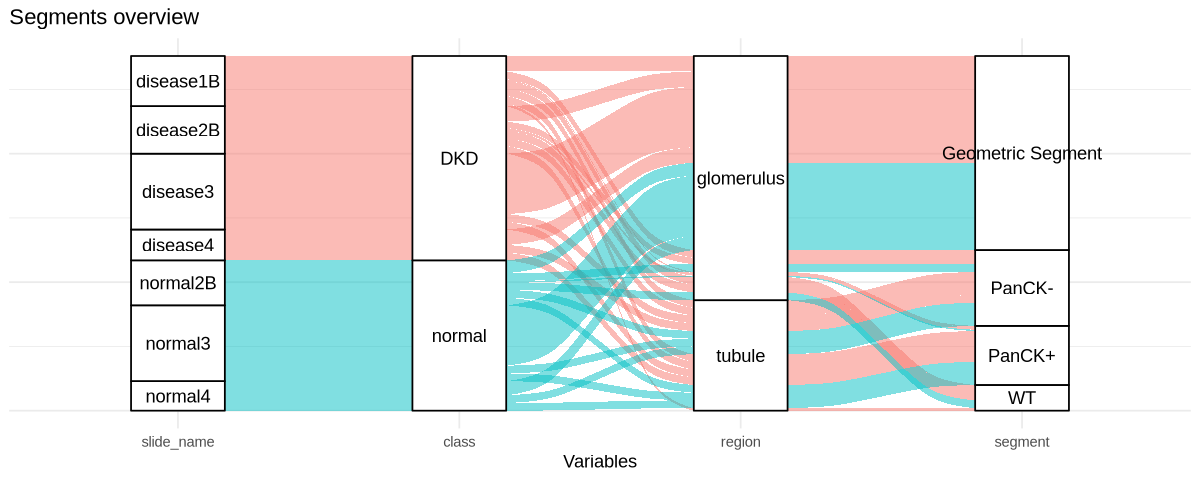

In [432]:
options(repr.plot.width = 10, repr.plot.height = 4)
library(ggalluvial)

df = dplyr::count(pData(geomxdt), slide_name, class, region, segment) %>% filter(slide_name != 'No Template Control')

ggplot(df, aes(axis1 = slide_name, axis2 = class, axis3 = region, axis4 = segment, y = n)) +
  geom_alluvium(aes(fill = class)) + geom_stratum() + theme_minimal() +
  scale_x_discrete(limits = c('slide_name', 'class', 'region', 'segment')) +
  theme(axis.text.y = element_blank(), legend.position = 'none') + 
  geom_text(stat = "stratum", aes(label = after_stat(stratum))) +
  labs(title = "Segments overview", x = 'Variables', y = NULL)

In [433]:
ix = with( pData(geomxdt), (region == 'glomerulus' & segment == 'Geometric Segment') | (region == 'tubule' & grepl('PanCK', segment)))
ix[is.na(ix)] <- FALSE

geomxdt <- geomxdt[,ix]

dim(geomxdt)

Features  Samples 
   18642      235

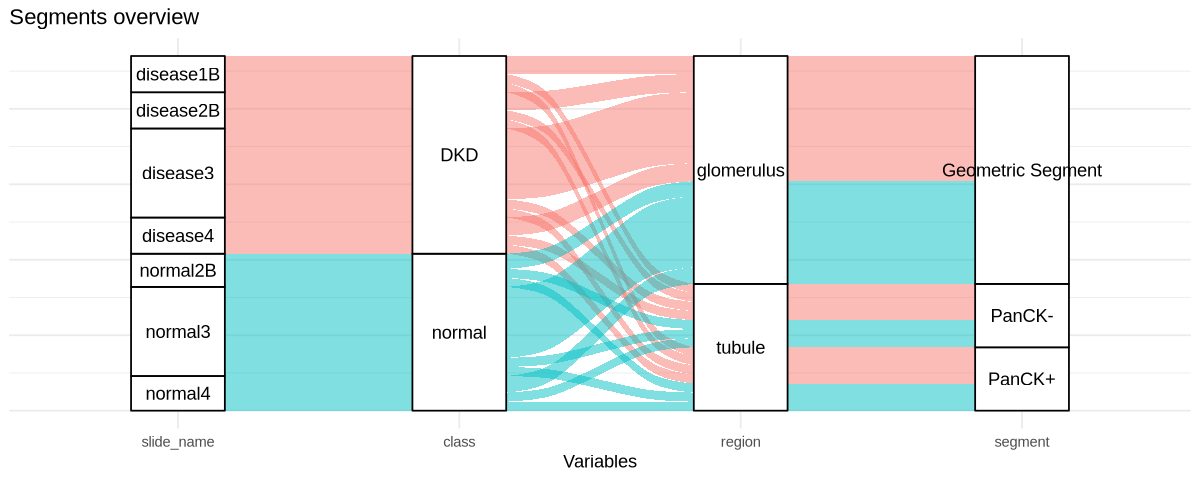

In [434]:
options(repr.plot.width = 10, repr.plot.height = 4)

df = dplyr::count(pData(geomxdt), slide_name, class, region, segment) 

ggplot(df, aes(axis1 = slide_name, axis2 = class, axis3 = region, axis4 = segment, y = n)) +
  geom_alluvium(aes(fill = class)) + geom_stratum() + theme_minimal() +
  scale_x_discrete(limits = c('slide_name', 'class', 'region', 'segment')) +
  theme(axis.text.y = element_blank(), legend.position = 'none') + 
  geom_text(stat = "stratum", aes(label = after_stat(stratum))) +
  labs(title = "Segments overview", x = 'Variables', y = NULL)

## QC & preprocessing

**Negative probes (or No template control probes)** are used to establish the background count level per segment. They represent synthetic oligonucleotide probes that are not complementary to any known transcript in the organism of interest, representing background noise (Non-specific binding, autofluorescence, instrument noise, etc).

### 1. Segment QC

***Filtering Criteria***

-   **Raw seq reads**: Segments with \< 1000 raw reads are removed.

-   **%aligned, % trimmed**\stitched reads: Segments \<80% for any of this are removed.

-   **%Sequence saturation** ($1-\frac{Unique\ reads}{Aligned\ reads}$%): Segments \< 50% require more reads and should not be analyzed.

-   **Negative Count**: Geometric mean of unique negative probes of the panel that do not target mRNA but are to establish background count level per segment.

-   **No template control (NTC) count**: Values \>1K are likely contamination for segments associated with this NTC. If value is between 1K to 10K segments can be used if NTC data is uniformly low (0-2 counts for all probes).

-   **Nuclei**: \>100 nuclei per segment is recommended. Study dependent, the key is to notice consistency across the segments.

-   **Area**: Tends to correlate with nuclei, not a strict cutoff.

In [467]:
geomxdt <- readRDS(file = file.path(out_dir,'geomxdt_raw.rds'))
## Initial transformations: Add count of 1 to all the counts. 
geomxdt <- shiftCountsOne(geomxdt, useDALogic = T) ## Make sure to remove 1 when saving counts matrix.

In [468]:
protocolData(geomxdt) %>% head()
## Print all varLabels in the protocol data.
varLabels(protocolData(geomxdt))

protocolData(geomxdt)[['ProbeCounts']]

An object of class 'AnnotatedDataFrame'
  sampleNames: DSP-1001250007851-H-A01.dcc DSP-1001250007851-H-A02.dcc
    ... DSP-1001250007851-H-A06.dcc (6 total)
  varLabels: FileVersion SoftwareVersion ... aoi (16 total)
  varMetadata: labelDescription

[1] "FileVersion"       "SoftwareVersion"   "Date"             
 [4] "SampleID"          "Plate_ID"          "Well"             
 [7] "SeqSetId"          "Raw"               "Trimmed"          
[10] "Stitched"          "Aligned"           "umiQ30"           
[13] "rtsQ30"            "DeduplicatedReads" "roi"              
[16] "aoi"

NULL

In [469]:

## If No Template Control count (NTC) is not there, and there are Negative Probes in the set, calculate NTC value.
protocolData(geomxdt)[['ProbeCounts']] <- colSums( exprs(geomxdt)) 

ix <- fData(geomxdt) %>% filter(grepl('Probe', TargetName))
if(nrow(ix) > 0){
  ## NTC = Counts in Negative probes.
   protocolData(geomxdt)[['NTC']] <- colSums( exprs(geomxdt)[ix$RTS_ID,]) 
   ## % of Negative Probe Counts / Counts in valid probes.
   ix <- fData(geomxdt) %>% filter(!grepl('Probe', TargetName))
   protocolData(geomxdt)[['NegProbe_pct']] <- (protocolData(geomxdt)[['NTC']] / colSums( exprs(geomxdt)[ix$RTS_ID,] ) ) * 100
}

In [470]:
# Default QC cutoffs are commented in () adjacent to the respective parameters
# study-specific values were selected after visualizing the QC results in detail
QC_params =
    list(minSegmentReads = 1000, # Minimum number of reads (1000)
         percentTrimmed = 80,    # Minimum % of reads trimmed (80%)
         percentStitched = 80,   # Minimum % of reads stitched (80%)
         percentAligned = 80,    # Minimum % of reads aligned (80%)
         percentSaturation = 50, # Minimum sequencing saturation (50%)
         minNegativeCount = 1.2,   # Minimum negative control counts (10)
         maxNTCCount = 10000,     # Maximum counts observed in NTC well (10000) -> Upper limit
         minNuclei = 20,       # Minimum # of nuclei estimated (100)
         minArea = 1000          # Minimum area of segment (1000) - Obligatory, otherwise it sets to a default threshold
)         

geomxdt = setSegmentQCFlags(geomxdt,  qcCutoffs = QC_params)        

# Collate QC Results
QCResults = protocolData(geomxdt)[["QCFlags"]]
QC_Summary = data.frame(Pass = colSums(!QCResults), Warning = colSums(QCResults))
QCResults$QCStatus <- apply(QCResults, 1L, function(x) {
    ifelse(sum(x) == 0L, "PASS", "WARNING")
})
QC_Summary["Total Flags", ] <-
    c(sum(QCResults[, "QCStatus"] == "PASS"),
      sum(QCResults[, "QCStatus"] == "WARNING"))

QC_Summary

,Pass,Warning
,<dbl>,<dbl>
LowReads,276,4
LowTrimmed,280,0
LowStitched,274,6
LowAligned,267,13
LowSaturation,276,4
LowNegatives,258,22
HighNTC,280,0
LowNuclei,NA,NA
LowArea,NA,NA


If you have different cell types, use them as category for exploration of QC, if not, then check it by slides. 
In this case, we will use the segment variable, which is set to geometric segment for glomerulus, and PanCK or neg for tubules (proximal or distal).

In [471]:
col_by <- "segment"

# Graphical summaries of QC statistics plot function
QC_histogram <- function(assay_data = NULL,
                         annotation = NULL,
                         fill_by = NULL,
                         thr = NULL,
                         scale_trans = NULL) {
    plt <- ggplot(assay_data,
                  aes_string(x = paste0("unlist(`", annotation, "`)"),
                             fill = paste0('(', fill_by,')') )) +
        geom_histogram(bins = 50) +
        geom_vline(xintercept = thr, lty = "dashed", color = "black") +
        theme_bw() + guides(fill = "none") +
        facet_wrap(as.formula(paste("~", fill_by)), nrow = 4) +
        labs(x = annotation, y = "Segments, #", title = annotation)
    if(!is.null(scale_trans)) {
        plt <- plt +
            scale_x_continuous(trans = scale_trans)
    }
    plt
}

#### Trimmed reads

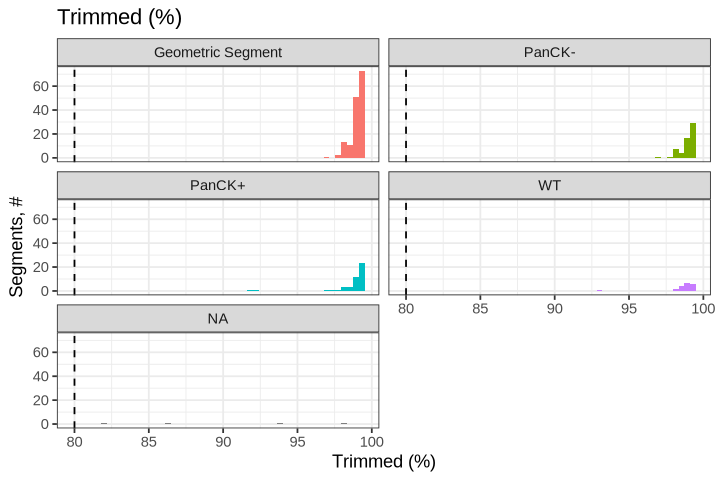

In [472]:
options(repr.plot.width = 6, repr.plot.height = 4)

QC_histogram(sData(geomxdt), "Trimmed (%)", col_by, QC_params$percentTrimmed)

#### Stitched reads

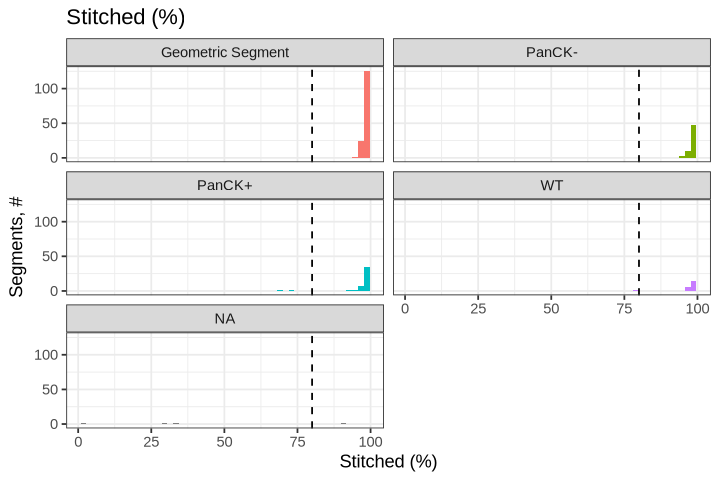

In [473]:
QC_histogram(sData(geomxdt), "Stitched (%)", col_by, QC_params$percentStitched)

#### Aligned reads

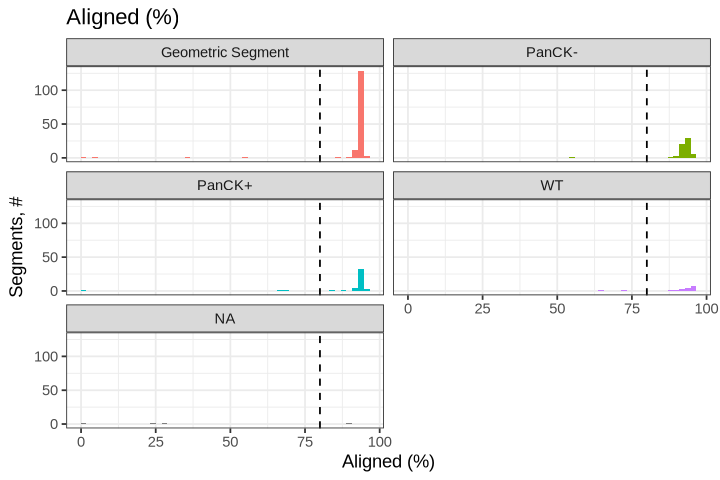

In [474]:
QC_histogram(sData(geomxdt), "Aligned (%)", col_by, QC_params$percentAligned)

#### Sequence saturation

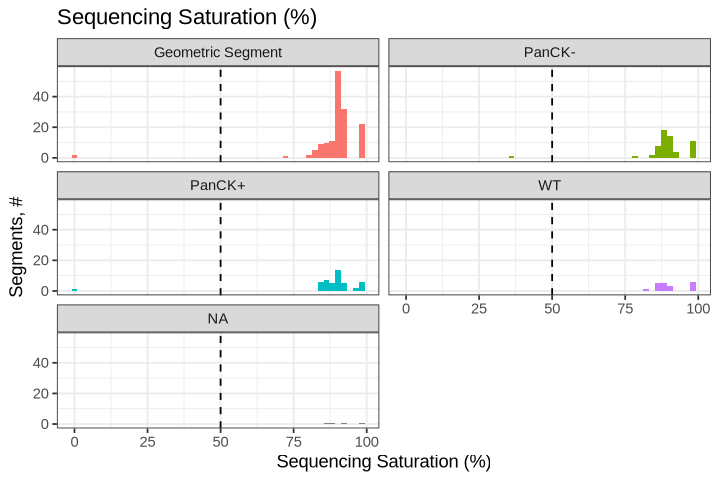

In [475]:
QC_histogram(sData(geomxdt), "Saturated (%)", col_by, QC_params$percentSaturation) +
    labs(title = "Sequencing Saturation (%)", x = "Sequencing Saturation (%)")

#### Area and number of nuclei

When data is available, explore these variables, there should be correlation between both, but all this should be guided by your biological expectations (Cell type, tissue, phenotype)

#### Number of nuclei

Warning message:
“Removed 4 rows containing non-finite outside the scale range (`stat_bin()`).”


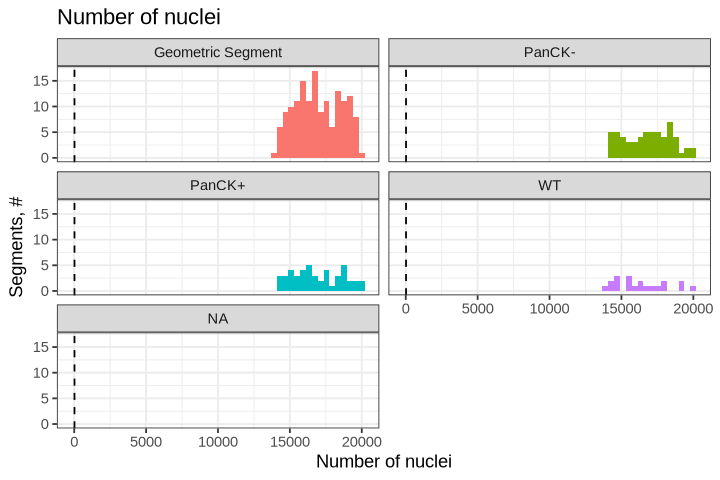

In [476]:
QC_histogram(sData(geomxdt), "nuclei", col_by, QC_params$minNuclei) +
    labs(title = "Number of nuclei", x = "Number of nuclei")

#### Segment area

When the number of nuclei is available, explore this variables. There should be correlation between number of nuclei and segment area, but all this should be guided by your biological expectations (Cell type, tissue, phenotype)

Warning message:
“Removed 4 rows containing non-finite outside the scale range (`stat_bin()`).”


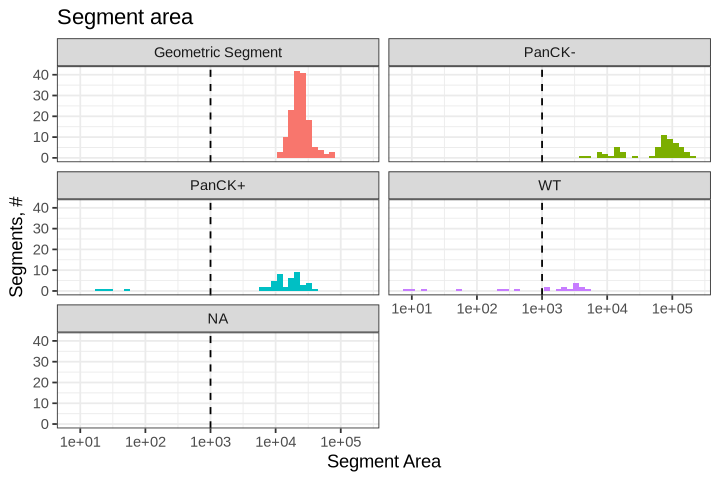

In [477]:
QC_histogram(sData(geomxdt), "area", col_by, QC_params$minArea, scale_trans = "log10") +
    labs(title = "Segment area", x = "Segment Area")

Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_point()`).”


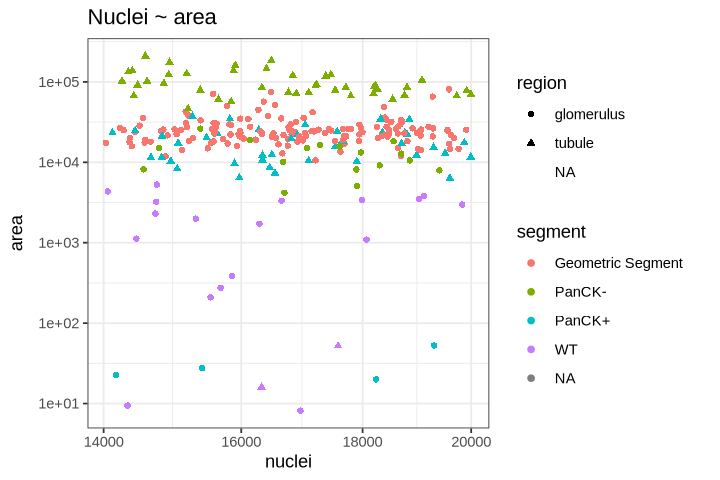

In [478]:
options(repr.plot.width = 6, repr.plot.height = 4)
ggplot(sData(geomxdt), aes(x = nuclei, y = area, color = segment, shape = region)) + geom_point() + 
  scale_x_log10() + scale_y_log10() +
  theme_bw() + labs(title = 'Nuclei ~ area') 

#### NTC Count

In this case, we have multiple samples with NTC Counts above 1k, but in most cases are below 10k.

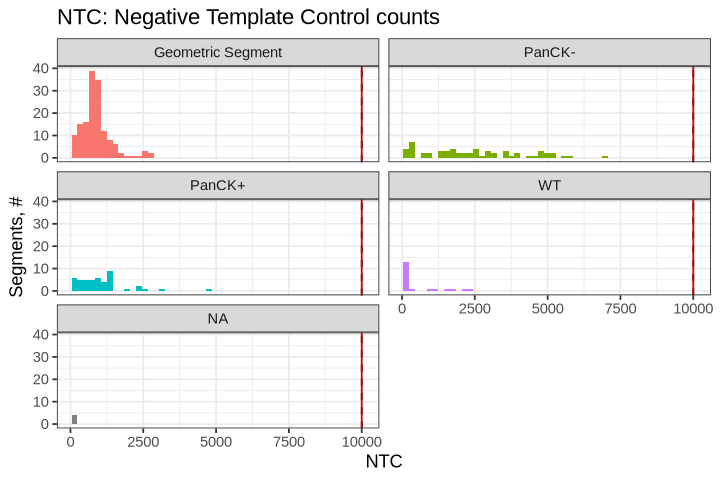

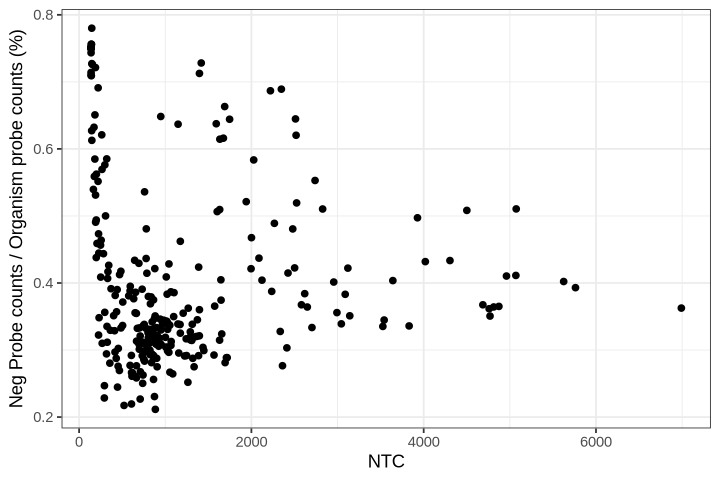

In [479]:
options(repr.plot.width = 6, repr.plot.height = 4)
QC_histogram(sData(geomxdt), "NTC", col_by, QC_params$maxNTCCount) +
    labs(title = "NTC: Negative Template Control counts", x = "NTC") + 
  geom_vline(xintercept = 10000, color = 'red3')


sData(geomxdt) %>% ggplot(aes(x = NTC, y = NegProbe_pct)) + geom_point() + theme_bw() + 
  labs(x = 'NTC', y = 'Neg Probe counts / Organism probe counts (%)')

#### Geometric Means of negative probes.

The calculation of Geometric Mean of negative probes per segment, this is done by module (If more than 1 probe panel used, each module represents a probe panel).

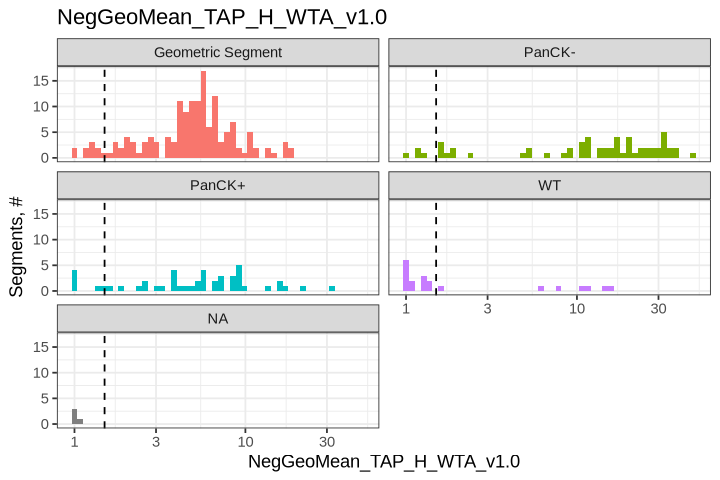

In [480]:
# calculate the Geometric means of negative probes for each module
negativeGeoMeans <- 
    esBy(negativeControlSubset(geomxdt), 
         GROUP = "Module", 
         FUN = function(x) { 
           ## Get Negative Geometric mean per segment.
             assayDataApply(x, MARGIN = 2, FUN = ngeoMean, elt = "exprs") 
         }) 
protocolData(geomxdt)[["NegGeoMean"]] <- negativeGeoMeans

# explicitly copy the geoMeans of Negative probes from sData to pData
negCols <- paste0("NegGeoMean_", modules)
pData(geomxdt)[, negCols] <- sData(geomxdt)[["NegGeoMean"]]
for(ann in negCols) {
    plt <- QC_histogram(pData(geomxdt), ann, col_by, 1.5, scale_trans = "log10")
    print(plt)
}

# detatch neg_geomean columns ahead of aggregateCounts call
pData(geomxdt) <- pData(geomxdt)[, !colnames(pData(geomxdt)) %in% negCols]

#### Segments statistics

In [481]:
knitr::kable(QC_Summary, caption = "QC Summary Table for each Segment")



Table: QC Summary Table for each Segment

|              | Pass| Warning|
|:-------------|----:|-------:|
|LowReads      |  276|       4|
|LowTrimmed    |  280|       0|
|LowStitched   |  274|       6|
|LowAligned    |  267|      13|
|LowSaturation |  276|       4|
|LowNegatives  |  258|      22|
|HighNTC       |  280|       0|
|LowNuclei     |   NA|      NA|
|LowArea       |   NA|      NA|
|Total Flags   |   NA|      NA|

#### Filter dataset

Filter performed so we keep segments that PASS all the QC criteria and also have a negative geometric mean greater than 1.

In [482]:
## Filter remove any Not Template Control segments.
ix = pData(geomxdt)$expected_neg == 0
geomxdt <- geomxdt[,ix]
QCResults <- QCResults[ix,]

In [483]:
dim(geomxdt)

## Index of segments QC: Check whether samples PASSED or add a flag instead of warning. 
## Add Flag: If it did not pass, flag is why. 
QCResults$Flag <- select(QCResults, -QCStatus) %>% 
  apply(1, function(x) ifelse(sum(x)==0,'PASS', paste(names(QCResults)[which(x)], collapse=',')))

## Gather the metadata for ALL samples, and add a FLAG about whether they passed or not. 
x <- sData(geomxdt) %>% dplyr::select(-FileVersion, -SoftwareVersion, -QCFlags) %>% rownames_to_column('segment_name')
for(i in which(map(x, ~class(.x)[1]) %in% c('data.frame', 'matrix'))){ x[[i]] = x[[i]][,1]  }
x <- cbind(x, select(QCResults, QCStatus, Flag))

write_tsv(x, file = file.path(out_dir,'segment_metadata_QC.tsv'))

## Filter by initial QC and also the negativeGeometricMeans per probe in each segment. 
geomxdt <- geomxdt[, QCResults$QCStatus == "PASS"]
# Subsetting our dataset has removed samples which did not pass QC
dim(geomxdt)


Features  Samples 
   18642      276

Features  Samples 
   18642      254

### 2. Probe QC

The goal is to remove low performance probes, which can be due to poor hybridization, low specificity, or other technical issues. 
WTA libraries have one probe per gene.

A probe should be removed if: 
  *_Geometric mean of probe counts across segments  / geometric mean of all probe counts < 0.1_*

In [484]:
geomxdt <- setBioProbeQCFlags(geomxdt, 
                               qcCutoffs = list(minProbeRatio = 0.1,
                                                percentFailGrubbs = 20), 
                               removeLocalOutliers = TRUE)

ProbeQCResults <- fData(geomxdt)[["QCFlags"]]

qc_df <- data.frame(Passed = sum(rowSums(ProbeQCResults[, -1]) == 0),
                    Global = sum(ProbeQCResults$GlobalGrubbsOutlier),
                    Local = sum(rowSums(ProbeQCResults[, -2:-1]) > 0
                                & !ProbeQCResults$GlobalGrubbsOutlier))

qc_df %>% knitr::kable(caption = 'Probes flagged or passed as outliers')



Table: Probes flagged or passed as outliers

| Passed| Global| Local|
|------:|------:|-----:|
|  18617|      1|    24|

In [485]:
geomxdt <- 
    subset(geomxdt, 
           fData(geomxdt)[["QCFlags"]][,c("LowProbeRatio")] == FALSE &
               fData(geomxdt)[["QCFlags"]][,c("GlobalGrubbsOutlier")] == FALSE)
dim(geomxdt)
#> Features  Samples 
#>     18814      207

Features  Samples 
   18641      254

### 3. Gene-level count data

In [486]:
# Check how many unique targets the object has
length(unique(featureData(geomxdt)[["TargetName"]]))
#> [1] 18504

# collapse to targets
target_data <- aggregateCounts(geomxdt)
dim(target_data)
#> Features  Samples 
#>    18504      254

## Save raw tables: Counts, features + segment metadata
counts <- (exprs(target_data) - 1) %>% as.data.frame() %>% rownames_to_column('TargetName')
features <- fData(target_data)
meta_cols = c('Sample_ID', 'slide_name', 'region', 'segment', 'class', 'aoi', 'roi', 'area', 'nuclei', 'pathology')
sam_anno <- pData(target_data) %>% dplyr::select(any_of(meta_cols)) %>% rownames_to_column('segment_name') 

## Write tables to tsv. 
write_tsv(counts, file.path(out_dir,'raw_counts.tsv'))
write_tsv(features, file = file.path(out_dir,'raw_features.tsv'))
write_tsv(sam_anno, file = file.path(out_dir,'raw_metadata.tsv'))

[1] 18504

Features  Samples 
   18504      254

### 4. Limit of quantification

Limit of quantification per segment, calculated on the distribution of negative control probes, and is intended to approximate the quantifiable limit of gene expression per segment. This metric is more stable in larger segments, also not great for segments with low negative probe counts.

$LOQ=Geometric\ Mean(NegProbe)*Geometric\ SD(NegProbe)^n$ *, where n is normally equal to 2.*

LOQ with a minimum of 2 as threshold, and the n variable is related to the number of SD to be used.

In [487]:
# Define LOQ SD threshold and minimum value
n = 2 ## Number of SD to be used, normally 2.
minLOQ = 2

# Calculate LOQ per module tested
LOQ = data.frame(row.names = colnames(target_data))
for(module in modules) {
    vars <- paste0(c("NegGeoMean_", "NegGeoSD_"), module)
    if(all(vars[1:2] %in% colnames(pData(target_data)))) {
        LOQ[, module] <- pmax(minLOQ, pData(target_data)[, vars[1]] * pData(target_data)[, vars[2]] ^ n)
    }
}
pData(target_data)$LOQ = LOQ
pData(target_data)$segment_name = rownames(pData(target_data))

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


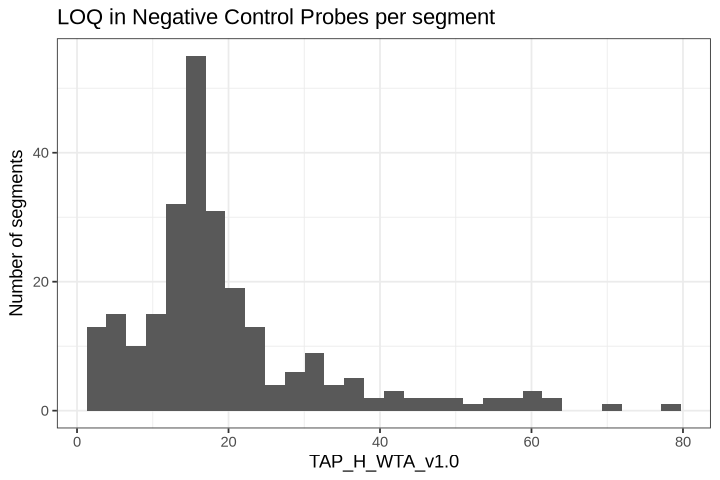

In [488]:
options(repr.plot.width = 6, repr.plot.height = 4)

ggplot(pData(target_data)$LOQ, aes(x = TAP_H_WTA_v1.0)) + geom_histogram() + theme_bw() + 
  labs(y = 'Number of segments', title = 'LOQ in Negative Control Probes per segment')

### 5. Filtering

After determining the limit of quantification (LOQ) per segment, we recommend filtering out either segments and/or genes with abnormally low signal. Filtering is an important step to focus on the true biological data of interest.

We determine the number of genes detected in each segment across the dataset.

In [489]:
## Matrix: Gene * segment: Is this gene counts higher than then segment LOQ for Negative probes.
LOQ_Mat <- c()
for(module in modules) {
    ind <- fData(target_data)$Module == module
    Mat_i <- t(esApply(target_data[ind, ], MARGIN = 1,
                       FUN = function(x) {
                           x > LOQ[, module]
                       }))
    LOQ_Mat <- rbind(LOQ_Mat, Mat_i)
}
# ensure ordering since this is stored outside of the geomxSet
LOQ_Mat <- LOQ_Mat[fData(target_data)$TargetName, ]

#### Segment gene detection

We first filter out segments with exceptionally low signal. These segments will have a small fraction of panel genes detected above the LOQ relative to the other segments in the study. Let's visualize the distribution of segments with respect to their % genes detected:

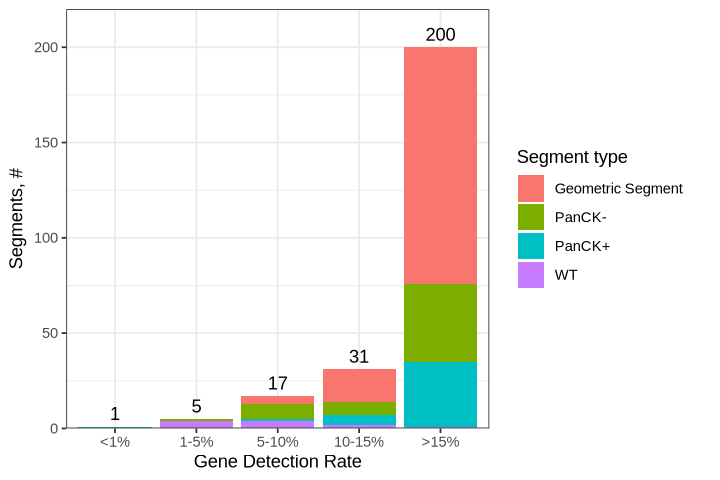

In [490]:
# Save detection rate information to pheno data
pData(target_data)$GenesDetected <- colSums(LOQ_Mat, na.rm = TRUE)
pData(target_data)$GeneDetectionRate <- pData(target_data)$GenesDetected / nrow(target_data)

# Determine detection thresholds: 1%, 5%, 10%, 15%, >15%
pData(target_data)$DetectionThreshold <- 
    cut(pData(target_data)$GeneDetectionRate,
        breaks = c(0, 0.01, 0.05, 0.1, 0.15, 1),
        labels = c("<1%", "1-5%", "5-10%", "10-15%", ">15%"))

# stacked bar plot of different cut points (1%, 5%, 10%, 15%)
ggplot(pData(target_data),
       aes(x = DetectionThreshold)) +
    geom_bar(aes(fill = segment)) +
    geom_text(stat = "count", aes(label = ..count..), vjust = -0.5) +
    theme_bw() +
    scale_y_continuous(expand = expansion(mult = c(0, 0.1))) +
    labs(x = "Gene Detection Rate",
         y = "Segments, #",
         fill = "Segment type")

In this example, we choose to remove segments with less than 10% of the genes detected. Generally, 5-10% detection is a reasonable segment filtering threshold. However, based on the experimental design (e.g. segment types, size, nuclei) and tissue characteristics (e.g. type, age), these guidelines may require adjustment.

In [491]:
target_data <- target_data[, pData(target_data)$GeneDetectionRate >= .1]

dim(target_data)

Features  Samples 
   18504      231

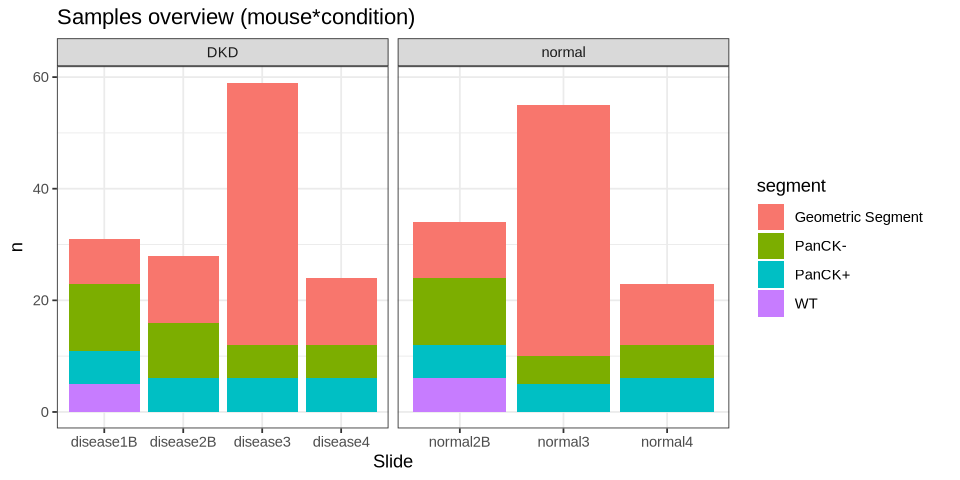

In [492]:
options(repr.plot.width = 8, repr.plot.height = 4)
count_mat = dplyr::count(sData(geomxdt), class, region, segment, slide_name) %>% 
  mutate(Slide = gsub('^.+ (S\\d)-.+$', '\\1', slide_name))

## Current 
ggplot(count_mat, aes(x = Slide, y = n, fill = segment)) + 
  geom_bar(stat = 'identity') + facet_grid(~class, scales = 'free_x') +
  theme_bw() + labs(title = 'Samples overview (mouse*condition)') 

#### Gene detection rate

Next, we determine the detection rate for genes across the study. To illustrate this idea, we create a small gene list (goi) to review.

We can see that individual genes are detected to varying degrees in the segments, which leads us to the next QC we will perform across the dataset.

In [493]:
# Calculate detection rate:
LOQ_Mat <- LOQ_Mat[, colnames(target_data)]
fData(target_data)$DetectedSegments <- rowSums(LOQ_Mat, na.rm = TRUE)
fData(target_data)$DetectionRate <-
    fData(target_data)$DetectedSegments / nrow(pData(target_data))

#### Gene filtering

We will graph the total number of genes detected in different percentages of segments. Based on the visualization below, we can better understand global gene detection in our study and select how many low detected genes to filter out of the dataset. Gene filtering increases performance of downstream statistical tests and improves interpretation of true biological signal.

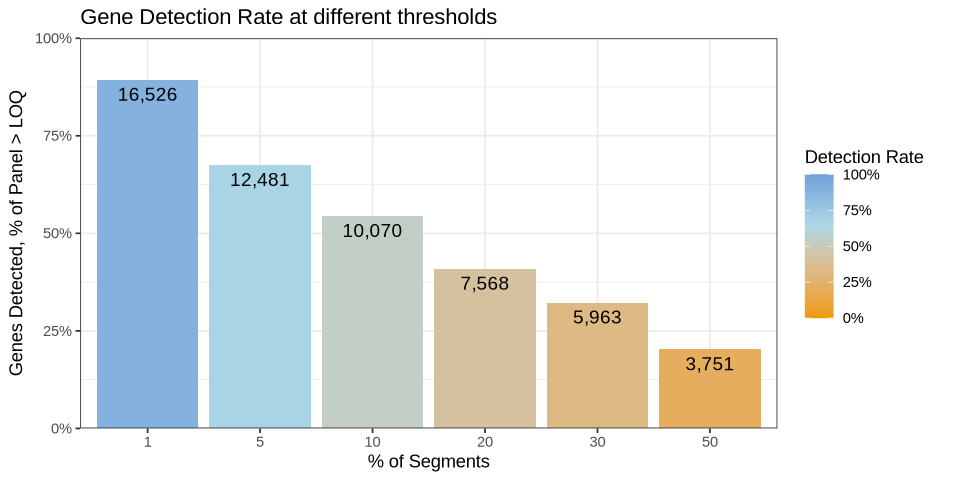

In [494]:
# Plot detection rate:
plot_detect <- data.frame(Freq = c(1, 5, 10, 20, 30, 50))
plot_detect$Number <-
    unlist(lapply(c(0.01, 0.05, 0.1, 0.2, 0.3, 0.5),
                  function(x) {sum(fData(target_data)$DetectionRate >= x)}))
plot_detect$Rate <- plot_detect$Number / nrow(fData(target_data))
rownames(plot_detect) <- plot_detect$Freq

ggplot(plot_detect, aes(x = as.factor(Freq), y = Rate, fill = Rate)) +
    geom_bar(stat = "identity") +
    geom_text(aes(label = formatC(Number, format = "d", big.mark = ",")),
              vjust = 1.6, color = "black", size = 4) +
    scale_fill_gradient2(low = "orange2", mid = "lightblue",
                         high = "dodgerblue3", midpoint = 0.65,
                         limits = c(0,1),
                         labels = scales::percent) +
    theme_bw() +
    scale_y_continuous(labels = scales::percent, limits = c(0,1),
                       expand = expansion(mult = c(0, 0))) +
    labs(x = "% of Segments",
         y = "Genes Detected, % of Panel > LOQ", fill = "Detection Rate", title = "Gene Detection Rate at different thresholds")

We typically set a % Segment cutoff ranging from 5-20% based on the biological diversity of our dataset. For this study, we will select 10% as our cutoff. In other words, we will focus on the genes detected in at least 10% of our segments; we filter out the remainder of the targets.

Note: if we know that a key gene is represented in only a small number of segments (\<10%) due to biological diversity, we may select a different cutoff or keep the target gene by manually selecting it for inclusion in the data object.

In [495]:
# Subset to target genes detected in at least 10% of the samples.
#   Also manually include the negative control probe, for downstream use
negativeProbefData <- subset(fData(target_data), CodeClass == "Negative")
neg_probes <- unique(negativeProbefData$TargetName)
target_data <- 
    target_data[fData(target_data)$DetectionRate >= 0.1 |
                        fData(target_data)$TargetName %in% neg_probes, ]
dim(target_data)
#> Features  Samples 
#>    10028      201

Features  Samples 
   10071      231

## Save Dataset

Save final tidy dataset as `NanoStringGeoMxSet`, also counts, features and metadata tables as well as `SpatialExperiment` dataset.

In [496]:
saveRDS(target_data, file = file.path(out_dir, 'tidy_geomx_obj.rds'))

## Save raw tables: Counts, features + segment metadata
counts <- (exprs(target_data) - 1) %>% as.data.frame() %>% rownames_to_column('TargetName')
features <- fData(target_data)
sam_anno <- sData(target_data) %>% dplyr::select(any_of(meta_cols)) %>% rownames_to_column('segment_name') 

## Write tables to csv. 
write_tsv(counts, file.path(out_dir,'tidy_counts.tsv'))
write_tsv(features, file = file.path(out_dir,'tidy_features.tsv'))
write_tsv(sam_anno, file = file.path(out_dir,'tidy_metadata.tsv'))

##########
## Save Spatial Experiment object.
#########
## Normalization -> Initial to save Spatial Experiment.- Q3
target_data <- normalize(target_data, 
                     fromElt = "exprs",
                     norm_method = "quant", 
                     desiredQuantile = .75,
                     toElt = "q_norm")


library(SpatialExperiment)
spe <- as.SpatialExperiment(target_data, normData = 'exprs')
assayNames(spe) <- 'counts' ## By default the function creates a GeoMx assay.
## Shuffle counts by 1 -> To ensure real counts by 1. 
assay(spe, 'counts') <- assay(spe, 'counts') -1 
assay(spe, 'normalized') <- assayDataElement(object = target_data, elt = "q_norm")
saveRDS(spe, file = file.path(out_dir, 'tidy_spe_obj.rds'))

## Session information

In [497]:
map(sessionInfo()$otherPkgs, ~.x$Version)

$ggalluvial
[1] "0.12.6"

$SpatialExperiment
[1] "1.12.0"

$SingleCellExperiment
[1] "1.24.0"

$SummarizedExperiment
[1] "1.32.0"

$GenomicRanges
[1] "1.54.1"

$GenomeInfoDb
[1] "1.38.1"

$IRanges
[1] "2.36.0"

$MatrixGenerics
[1] "1.14.0"

$matrixStats
[1] "1.5.0"

$GeomxTools
[1] "3.6.2"

$NanoStringNCTools
[1] "1.10.1"

$S4Vectors
[1] "0.40.2"

$Biobase
[1] "2.62.0"

$BiocGenerics
[1] "0.48.1"

$readxl
[1] "1.4.5"

$lubridate
[1] "1.9.4"

$forcats
[1] "1.0.0"

$stringr
[1] "1.5.2"

$dplyr
[1] "1.1.4"

$purrr
[1] "1.1.0"

$readr
[1] "2.1.5"

$tidyr
[1] "1.3.1"

$tibble
[1] "3.3.0"

$ggplot2
[1] "4.0.2"

$tidyverse
[1] "2.0.0"